In [ ]:
#import cupy as cp
import numpy as np
import scipy.signal as signal
import scipy.fft
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

### Introdução a filtros adaptativos
---
Um filtro adaptativo é um filtro digital que tem caracteristicas de autoajuste. Esses filtros desempenham um papel importante nos produtos modernos de processamento de sinal digital (DSP) em áreas como cancelamento de eco telefônico, cancelamento de ruído, equalização de canais de comunicação, entre outros. Os filtros adaptativos funcionam geralmente para a adaptação e sobreposição, pois em casos que o ruído de interferência é forte, usar um filtro tradicional não preservará o espctro de sinal desejado.

Para entender melhor o conceito de filtros adaptativos, podemos analisar um cancelador de ruídos simples. Conforme mostrado na figura abaixo, o sistema *DSP* consiste em dois canais de conversão **ADC**. O primeiro microfone captura a fala desejada. No entanto, devido ao ambiente ruidoso, o sinal é contaminado com o ruído. Um segundo microfone é usado para capturar o ruído, alimentando assim o fitro adaptativo.

<center><img src="https://github.com/Medupl/CoppeliaSim/blob/main/images/Optic/Cancelador-de-ruido.png?raw=true"/></center>
$$\text{Fonte: Livro: Digital Signal Processing: Fundamentals and Applications}$$

Neste exemplo podemos assumir que o sinal com ruído é uma versão linear da fonte do ruído, então podemos estimar o ruído no sinal desejado usando um filtro adaptativo, que possui um algoritmo de *Minimos Quadrados Médios* (**LMS**), que ajusta os coeficientes e quando temos $y(n) ≈ n(n)$, podemos usar a expressão de erro e então o ruído é cancelado. O filtro usado no exemplo acima é definido como *Filtro de resposta ao impulso* (**FIR**), o coeficiente $w(n)$ é ajustado pelo algoritmo **LMS**. Onde temos as seguintes expressões:
$$\begin{equation}
y(n) = w(n).x(n) \\
d(n) = s(n) + n(n) \\
e(n) = d(n) - y(n) \\
w(n + 1) = w(n) + 0.01.e(n).x(n)
\end{equation}$$

__Por que os filtros adaptativos são a melhor escolha?__

Filtros adaptativos são a melhor escolha em sistemas onde as características do ambiente ou do sinal variam ao longo do tempo e não podem ser modeladas de forma estática. Eles ajustam seus coeficientes automaticamente para minimizar erros ou alcançar objetivos específicos, como cancelamento de ruído, predição de sinais ou equalização de canais.

### Teoria básica do filtro Wiener
---
Muitos algoritmos adaptativos podem ser vistos como aproximações do filtro Wiener discreto, onde a saída $y(n)$ é uma soma ponderada, dada por:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$

O fitro Wiener ajusta sua saída para ser o mais próximo do ruído $n(n)$, assim, na saída o ruído é cancelado. Considere um caso de peso único de $y(n) = wx(n)$ e fazendo algumas manipulações temos:
$$e(n) = d(n) - wx(n) ⟹ e^2(n) = (d(n) - wx(n))^2 = d^2(n) - 2d(n)wx(n) + w^2x^2(n)$$

Usando a expectativa estatistica, temos:
$$E(e^2(n)) = E(d^2(n)) - 2wE(d(n)x(n)) + w^2E(x^2(n))$$
onde:
> $J = E(e^2(n)) =$ erro quadratico médio. \\
  $σ^2 = E(d^2(n)) =$ potência do sinal corrompido. \\
  $P = E(d(n)x(n)) =$ correlação cruzada de d(n) e x(n). \\
  $R = E(x^2(n)) = $ autocorrelação.

Substituindo na equação temos:
$$J = σ^2 - 2w.P + w^2.R$$

A melhor solução para o peso $w$ ocorre quando o $J_{min}$ é alcançado, assim quando fazemos a derivada igual a zero, temos:
$$\frac{dJ}{dw} = -2P + 2wR = 0 \\
w = P.R^{-1}$$

Em geral, o filtro Wiener tem N coeficientes e pode ser escrito em forma de matriz como:
$$\begin{equation}
y(n) = \sum_{k = 0}^{N - 1} w_k x(n - k) = W^T X(n)
\end{equation}$$

Fazendo essa alteração na função **MSE**, temos:
$$J = E(e^2(n)) = E(d(n) - W^TX(n))^2 \\ \begin{equation}
J = σ^2 - 2W^T.P + W^T.R.W
\end{equation}$$

Fazendo a derivada para zero, temos:
$$\frac{dJ}{dW} = -2.P + W.R = 0 \\
W = P. R^{-1}$$

__Qual a função do filtro de Wiener?__

O filtro de Wiener é um filtro projetado para minimizar o erro médio quadrático (MSE) entre o sinal desejado e o sinal estimado. Ele é usado em situações onde o sistema é estacionário e conhecido. Esse filtro ajuda a estimar valores futuros de um sinal baseado no histórico.

>**Prós:** \\
> + Fornece a solução ótima para sinais estacionários.
> + Minimiza o erro médio quadrático (MSE).

> __Contras:__ \\
+ Requer conhecimento prévio da estatística do sinal, o que não é viável em sistemas dinâmicos.
+ Mais complexo computacionalmente em comparação ao LMS.

### Previsão Linear Direta
---

A previsão linear lida com a probabilidade de prever um valor futuro a partir de valores passados observados. Considerando um ponto $x(n)$, usando valores de $x(n - 1) ⋯ x(n - P)$. A previsão pode ser obtida por:
$$\begin{equation}
  x´(n) = \sum_{k = 1}^{P} a_k x(n - k)
\end{equation}$$

A diferença entre $x(n) \ e \ x´(n)$ é dada pelo erro de previsão:
$$e_f(n) = x(n) - x´(n)$$

### Algoritmo de descida mais íngrime
---

Como vimos, resolver a solução de *Wiener* requer muitos cálculos, para isso usamos um algoritmo **LMS** que usa o algoritmo de descida mais íngrime para minimizar o **MSE**.
$$\begin{equation}
w(n + 1) = w(n) - μ\frac{dJ}{dw(n)}
\end{equation}$$

onde μ é a constante que controla a velocidade de convergência.

Para caso geral, temos: $y(n) = W(n)^T.X(n)$ \
Em forma vetorial: $w(n + 1) = W(n) - μΔJ_{W(n)}$

### Algoritmo de mínimos quadrados médios (**LMS**)
---

A aplicação do algoritmo de descida mais íngrime ainda inclui cálculos estatísticos de um bloco de dados. Para solucionar usamos um algortimo baseado em amostra **LMS**, onde:
$$J = e^2(n) = (d(n) - w(n)x(n))^2 \\
\frac{dJ}{dw(n)} = -2e(n)x(n)$$

Substituindo na expressão do filtro de descida, encontramos o *LMS* para atualizar um caso de peso único.
$$\begin{equation}
w(n + 1) = W(n) +2μ e(n)x(n)
\end{equation}$$
onde $ 0 < μ < \frac{1}{λ_{max}}, λ_{max}$ é o autovalor da matriz $R = E(X^T(n)X(n))$

Para caso geral, temos:
$$y(n) = w_0x(n) + w_1x(n - 1) + ⋯ + w_{N - 1}x(n - N + 1)$$
$$w_k(n + 1) = W_k(n) +2μ e(n)x(n - k)$$

Em forma vetorial: $W(n + 1) = W(n) +2μ e(n)X(n)$




### Exemplo 1
---
Neste exemplo, o algoritmo LMS é utilizado para cancelar ruídos adaptativamente, onde o sinal de entrada é contaminado por ruído e o filtro LMS ajusta-se para minimizar o erro entre o sinal desejado e o sinal de saída.

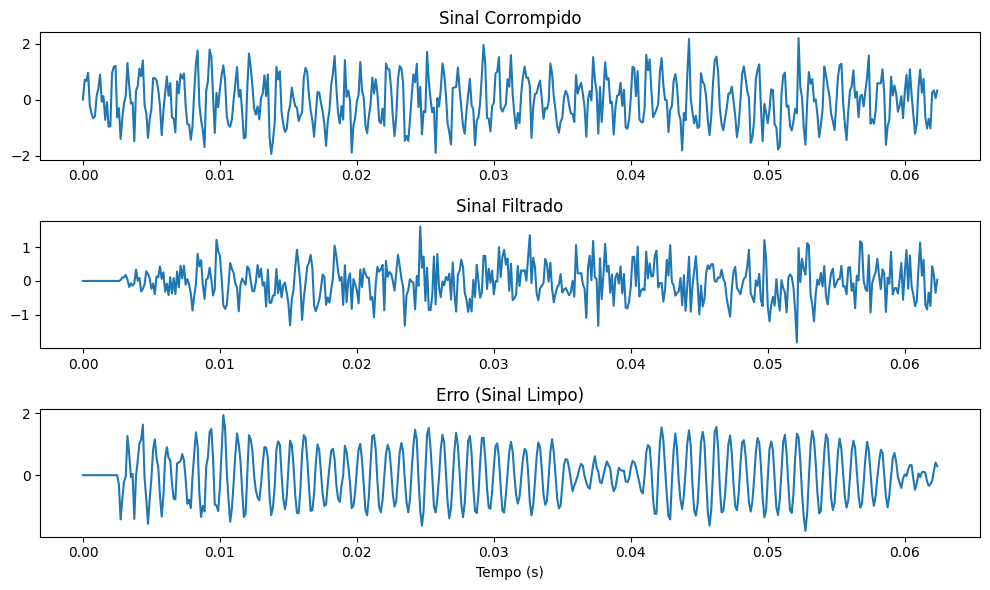

In [ ]:
# Parâmetros do sinal
fs = 8000
N = 500
mu = 0.01
t = np.arange(N) / fs

# Sinal e ruído
wen = np.sin(2 * np.pi * 1000 * t)
x = np.random.randn(N)
n = np.convolve(x, np.array([0, 0, 0, 0, 0.5]), mode='same')
d = wen + n

# Filtro LMS
w = np.zeros(21)
y = np.zeros(N)
e = np.zeros(N)
for m in range(21, N):
    y[m] = np.sum(w * x[m-21:m][::-1])
    e[m] = d[m] - y[m]
    w += 2 * mu * e[m] * x[m-21:m][::-1]

# Conversão para NumPy para visualização
"""
t = np.asnumpy(t)
d = np.asnumpy(d)
y = np.asnumpy(y)
e = np.asnumpy(e)"""

# Plotando os resultados
plt.figure(figsize=(10, 6))
plt.subplot(3, 1, 1)
plt.plot(t, d)
plt.title("Sinal Corrompido")

plt.subplot(3, 1, 2)
plt.plot(t, y)
plt.title("Sinal Filtrado")

plt.subplot(3, 1, 3)
plt.plot(t, e)
plt.title("Erro (Sinal Limpo)")
plt.xlabel("Tempo (s)")
plt.tight_layout()
plt.show()


### Identificação de Sistema Adaptativa com Algoritmo LMS
---
No processo de identificação de sistema adaptativa, o objetivo é modelar ou aproximar um sistema desconhecido usando um filtro adaptativo, geralmente um filtro FIR (Finite Impulse Response) ajustado com o algoritmo LMS (Least Mean Squares). Essa técnica é amplamente utilizada em cenários onde o comportamento de um sistema não é totalmente conhecido, mas um conjunto de entradas e saídas do sistema está disponível para análise.

Como Funciona o Algoritmo LMS na Identificação de Sistemas

+ Sinal de Entrada (x[n]): Um sinal conhecido, como um sinal senoidal ou ruído branco, é aplicado tanto ao sistema desconhecido quanto ao filtro adaptativo. Esse sinal funciona como uma entrada de teste para caracterizar o sistema.

+ Sistema Desconhecido: Esse sistema possui uma resposta ao impulso que queremos identificar. Quando o sinal de entrada passa pelo sistema desconhecido, ele gera uma saída desejada $d[n]$, que representa a resposta verdadeira do sistema.

+ Filtro Adaptativo: O filtro adaptativo tenta "aprender" a resposta ao impulso do sistema desconhecido. Inicialmente, o filtro começa com coeficientes arbitrários (geralmente zeros) e ajusta esses coeficientes a cada iteração para reduzir o erro.

+ Erro (e[n]): O erro é a diferença entre a saída do filtro adaptativo $(y[n])$ e a saída desejada $(d[n])$. Esse erro indica quão próximo o filtro está de imitar o sistema desconhecido.

+ Ajuste dos Coeficientes: Com base no erro, o algoritmo LMS ajusta os coeficientes do filtro adaptativo. Esse ajuste é feito para minimizar o erro médio quadrático (Mean Squared Error - MSE) entre a saída do filtro e a saída desejada, movendo os coeficientes na direção que reduz o erro.


### Exemplo
---
Espera-se que, ao final do processo de adaptação, o filtro LMS consiga imitar o comportamento do sistema desconhecido, resultando em um erro mínimo entre a saída do filtro e a saída desejada. Isso indica que o filtro foi capaz de identificar a estrutura do sistema desconhecido com precisão.

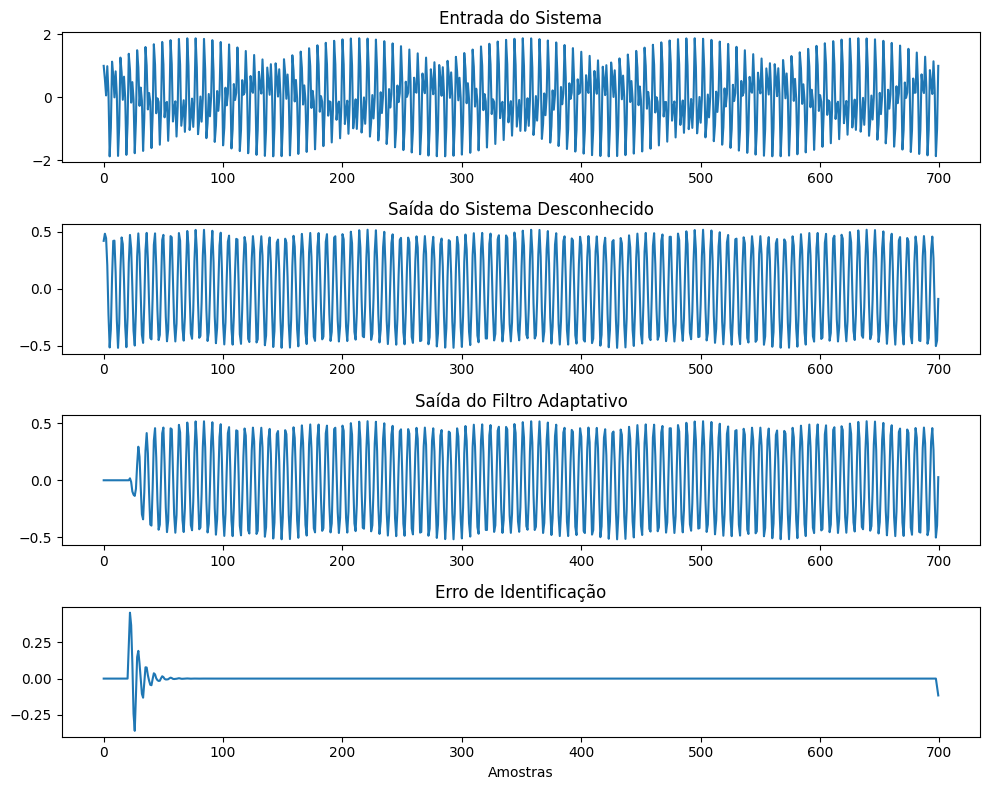

In [ ]:
# Sinal de entrada e parâmetros do sistema
fs = 700
t = np.linspace(0, 1, fs)
x = np.cos(2 * np.pi * 500 * t) + np.sin(2 * np.pi * 1500 * t)

# Sistema desconhecido (filtro passa-banda)
b = np.array([0.1, 0.2, 0.3, 0.2, 0.1])
d = np.convolve(x, b, mode='same')

# Filtro LMS
w = np.zeros(21)
y = np.zeros(fs)
e = np.zeros(fs)
mu = 0.01
for m in range(21, fs):
    y[m] = np.sum(w * x[m-21:m][::-1])
    e[m] = d[m] - y[m]
    w += 2 * mu * e[m] * x[m-21:m][::-1]

# Conversão para NumPy para visualização
"""
x = np.asnumpy(x)
d = np.asnumpy(d)
y = np.asnumpy(y)
e = np.asnumpy(e)"""

# Plotando resultados
plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(x)
plt.title("Entrada do Sistema")

plt.subplot(4, 1, 2)
plt.plot(d)
plt.title("Saída do Sistema Desconhecido")

plt.subplot(4, 1, 3)
plt.plot(y)
plt.title("Saída do Filtro Adaptativo")

plt.subplot(4, 1, 4)
plt.plot(e)
plt.title("Erro de Identificação")
plt.xlabel("Amostras")
plt.tight_layout()
plt.show()


__Cancelamento de Ruído (Noise Cancellation)__:

O cancelamento de ruído é uma técnica fundamental em processamento digital de sinais, usada para reduzir ou eliminar ruídos indesejados de sinais de interesse. O objetivo é melhorar a qualidade do sinal principal, isolando-o de interferências sonoras. A técnica mais comum para cancelamento de ruído é o uso de filtros adaptativos, especialmente o filtro LMS (Least Mean Square). Esse filtro aprende em tempo real a característica do ruído e o subtrai do sinal original. Um exemplo típico de aplicação é o cancelamento de ruído em comunicações telefônicas, onde interferências externas ou ruídos de fundo podem ser removidos sem comprometer a clareza do sinal de voz.

+ Principais Benefícios:
  - Melhoria da inteligibilidade do sinal.
  - Redução de interferências que podem comprometer a comunicação.
  - Aplicação em fones de ouvido com cancelamento de ruído ativo, onde o dispositivo é capaz de isolar sons indesejados para uma experiência auditiva mais limpa.


__Modelagem de Sistema (System Modeling):__

A modelagem de sistema refere-se à criação de um modelo matemático que representa as características de um sistema físico. Em processamento de sinais, a modelagem de sistemas é essencial para simular e prever o comportamento de sistemas complexos, como filtros ou canais de comunicação. A modelagem pode ser feita usando técnicas adaptativas, que permitem que o modelo ajuste automaticamente seus parâmetros com base nas condições de entrada. Esse processo é útil em sistemas onde as características variam ao longo do tempo e é necessário um acompanhamento dinâmico das mudanças.

+ Principais Benefícios:
  - Previsão e controle do comportamento de sistemas físicos complexos.
  - Otimização de desempenho em sistemas de comunicação, ao se adaptar a diferentes condições do canal.
  - Aplicação em engenharia para o desenvolvimento de sistemas robustos e eficientes.

### Referências
---
1. **Tan, L., & Jiang, J.**. *Digital Signal Processing: Fundamentals and Applications*. 3ª Edição. AP, 2019
2. **Moodle USP**. *Filtros de Wiener*. Disponível em: [https://edisciplinas.usp.br/.../aula5.pdf](https://edisciplinas.usp.br/pluginfile.php/5814216/mod_resource/content/1/APDS-Quarentena-aula5.pdf). Acessado em: 23 de novembro de 2024.
3. **Aprenda Fácil**. *O que é: Filtro de Wiener - Entenda sua Aplicação*. Disponível em: [https://estatisticafacil.org/glossario/o-que-e-filtro-de-wiener-aplicacao-e-teoria/](https://estatisticafacil.org/glossario/o-que-e-filtro-de-wiener-aplicacao-e-teoria/). Acessado em: 23 de novembro de 2024